# Data Science in Healthcare 
## Data Analysis Task - summative assessment  


You have been given access to data on patients attending an acute medical unit (AMU). An AMU is a specialist ward in a hospital which cares for patients who have a rapid onset of severe symptoms, and who therefore prompt treatment. The data contains measurements taken from patients at various time points, alongside other sociodemographic and health data.

You are asked to predict which adult patients have a critical incident within 72 hours of admission to the AMU (`crit_72`).

Your classification model should be usable on admission to the AMU. 

The `Data Analysis Task: data` folder on the VLE contains three files:
- `training_data.csv` – details of a subset of patients, with `crit_72` disclosed
- `test_data.csv` – details of a subset of patients, with `crit_72` not disclosed
- `data_dictionary.gdoc` – the data dictionary for these data 

*Note: These data are based on real patient data but are synthetic*

You will need to pre-process the training and test datasets. You are asked to include a binary feature representing whether a patient has multimorbidity (`1 = multimorbidity`, `0 = no multimorbidity`), based on `num_diagnoses`. Convert `num_diagnoses` into a binary feature, using an appropriate threshold. Justify your choice. Ensure you have shown some consideration of sample size requirements. 

Once you have pre-processed the data, you are asked to do two data analysis tasks:

**1 - Build an ensemble model** 

- Use the training data to build an ensemble model to predict `crit_72` 
- Show evidence that you have considered multiple different types of ensemble model
- Optimise your ensemble models for balanced accuracy score

Based on your findings, choose **one** of your ensemble models to take forward as your final model 

- Plot the calibration curve of your chosen ensemble, and recalibrate the predicted probabilities using an appropriate method
- Provide some interpretation of your final model
- Use your final model to predict the class label for those individuals in `test_data.csv`. Save your predicted classes as `y_predict_ensemble`. These predictions will be compared to `y_test`, which you do *not* have access to. The performance of your final ensemble model on the test data will contribute to your mark for this question

**2 - Build a logistic regression model**

- Use the training data to build a logistic regression model to predict `crit_72` 
- Assess the balanced accuracy score
- Based on your findings, would you recommend using this model instead of your ensemble model? Provide a comment that explains your choice. You do *not* need to use your logistic regression model to predict the class label for those individuals in `test_data.csv`.


Ensure your final notebook is complete and runs without error. If you cannot get any component of your code to run, then comment it out and explain what you were trying to do.

Your code should be commented, and you should also include text sections in your notebook providing additional background information and any references needed to explain your code.

[The marking rubric for the Data Analysis Task is available here](https://docs.google.com/document/d/1XwlJmmi8_iAgTHdD7-3pltPMdJ0_0oQDxZi1YlVBusg/edit?usp=sharing)

When you have finished, download this notebook as an .ipynb format, and upload it to the submission point called `Data Analysis Task: submission point` on the VLE by the deadline. 

You do not need to upload any data. 

You must include a cover sheet with your submission - this is available in the Assessment folder of the VLE (`PGT Cover Sheet`). You should put the word count as 'not applicable' on the cover sheet for this assignment.

## Data Analysis

In [ ]:
# reading in the training and test data
import pandas as pd

train = pd.read_csv('training_data.csv')
test = pd.read_csv('test_data.csv')

In [ ]:
# viewing first few rows of the training data
train.head()

,patient_id,abdominal,age,alcohol_dependent,alcohol_dependent_sr,arrival_mode,arrival_period,bmi,cardiac,chest_pain,...,meds_vitamins,num_diagnoses,num_prev_visits,nutrition,o2,pulse_1,pulse_2,sedation,triglycerides,vasopressors
0,54380870,0.0,40.0,0.0,0.0,0.0,1.0,24.379999,0.0,0.0,...,0.0,1.0,2.0,1.0,NaN,60.7,55.2,1.0,136.10001,1.0
1,99762057,0.0,53.0,1.0,1.0,0.0,1.0,24.629999,1.0,0.0,...,1.0,3.0,3.0,0.0,NaN,NaN,NaN,1.0,NaN,1.0
2,10969978,0.0,82.0,0.0,NaN,0.0,1.0,23.160000,1.0,0.0,...,0.0,2.0,10.0,1.0,NaN,77.8,69.3,0.0,129.30000,0.0
3,94206937,0.0,37.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,59462480,0.0,20.0,0.0,0.0,NaN,0.0,20.440001,0.0,0.0,...,0.0,0.0,0.0,0.0,NaN,75.3,72.0,1.0,NaN,0.0


<Axes: >

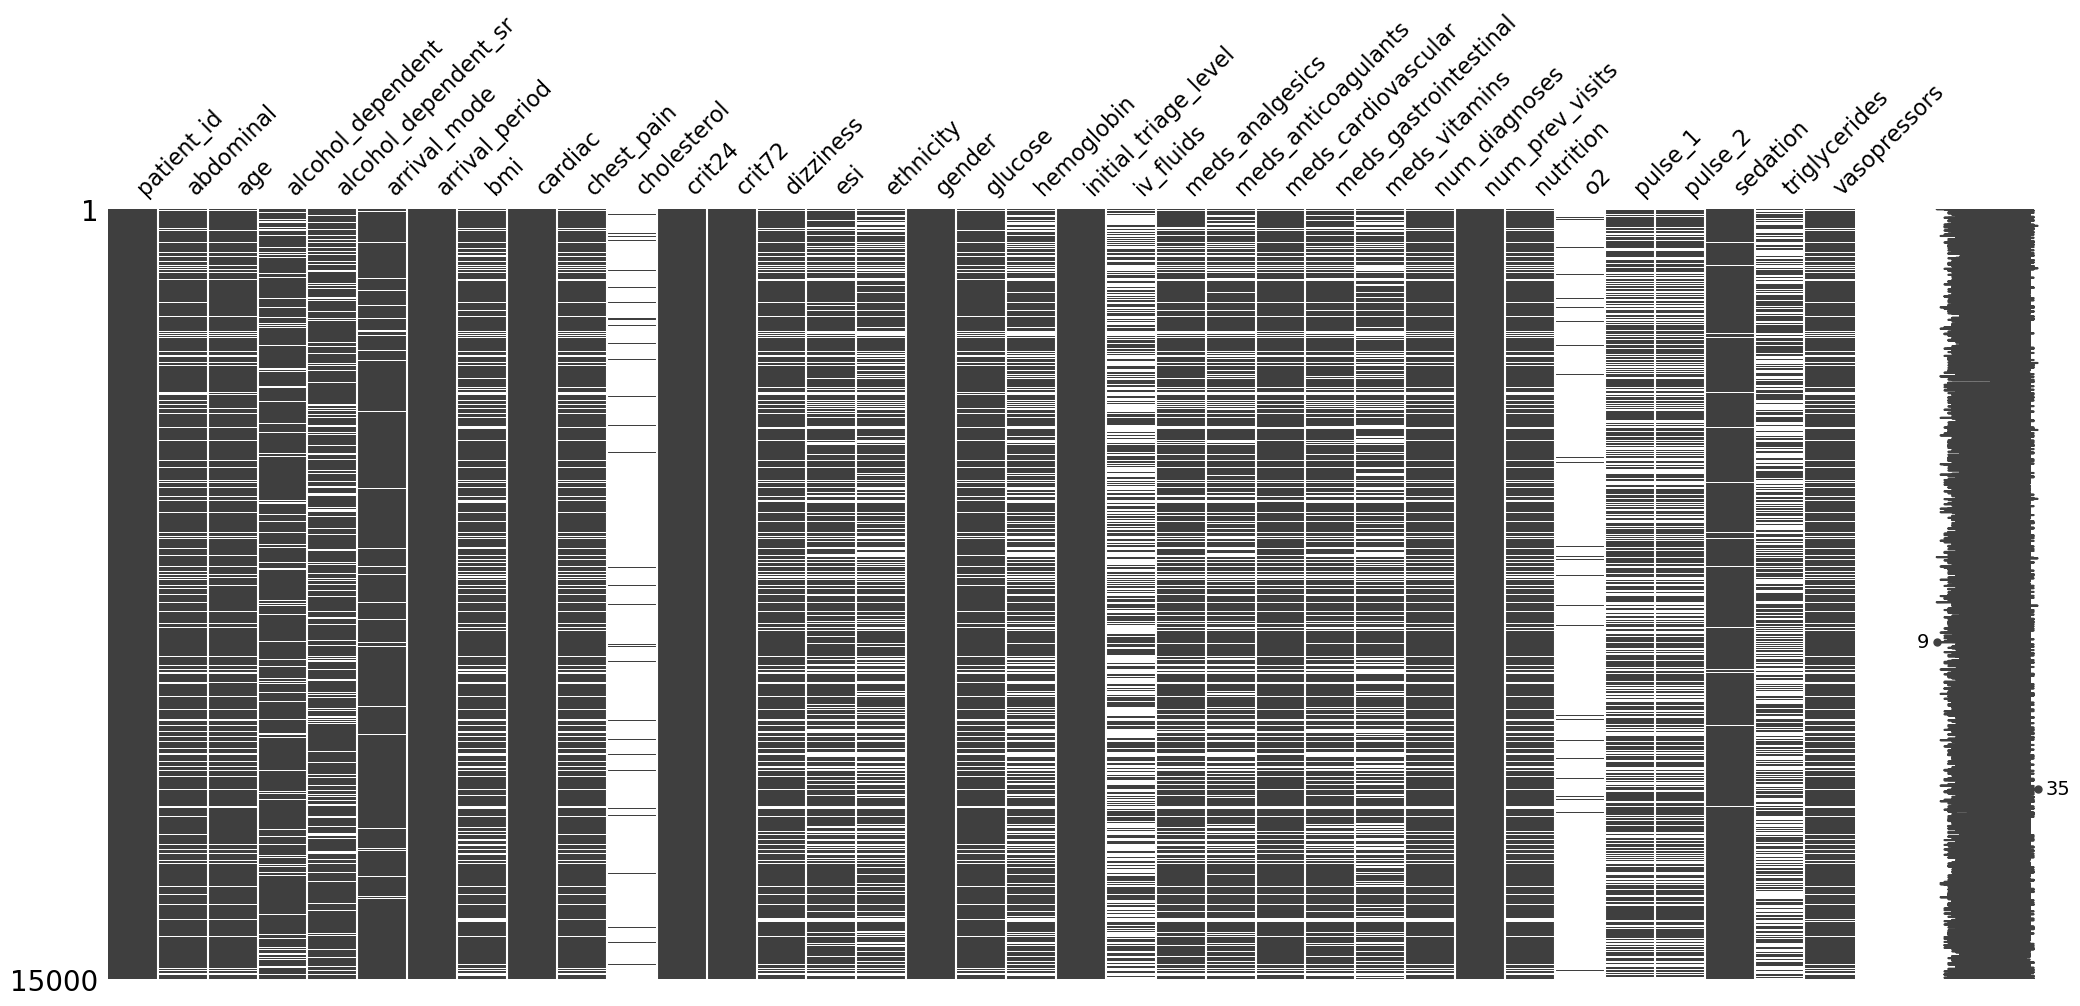

In [ ]:
# checking missingness in the training data
import missingno as msno
msno.matrix(train)

array([[<Axes: title={'center': 'patient_id'}>,
        <Axes: title={'center': 'abdominal'}>,
        <Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'alcohol_dependent'}>,
        <Axes: title={'center': 'alcohol_dependent_sr'}>,
        <Axes: title={'center': 'arrival_mode'}>],
       [<Axes: title={'center': 'arrival_period'}>,
        <Axes: title={'center': 'bmi'}>,
        <Axes: title={'center': 'cardiac'}>,
        <Axes: title={'center': 'chest_pain'}>,
        <Axes: title={'center': 'cholesterol'}>,
        <Axes: title={'center': 'crit24'}>],
       [<Axes: title={'center': 'crit72'}>,
        <Axes: title={'center': 'dizziness'}>,
        <Axes: title={'center': 'esi'}>,
        <Axes: title={'center': 'ethnicity'}>,
        <Axes: title={'center': 'glucose'}>,
        <Axes: title={'center': 'hemoglobin'}>],
       [<Axes: title={'center': 'initial_triage_level'}>,
        <Axes: title={'center': 'iv_fluids'}>,
        <Axes: title={'center': 'meds_anal

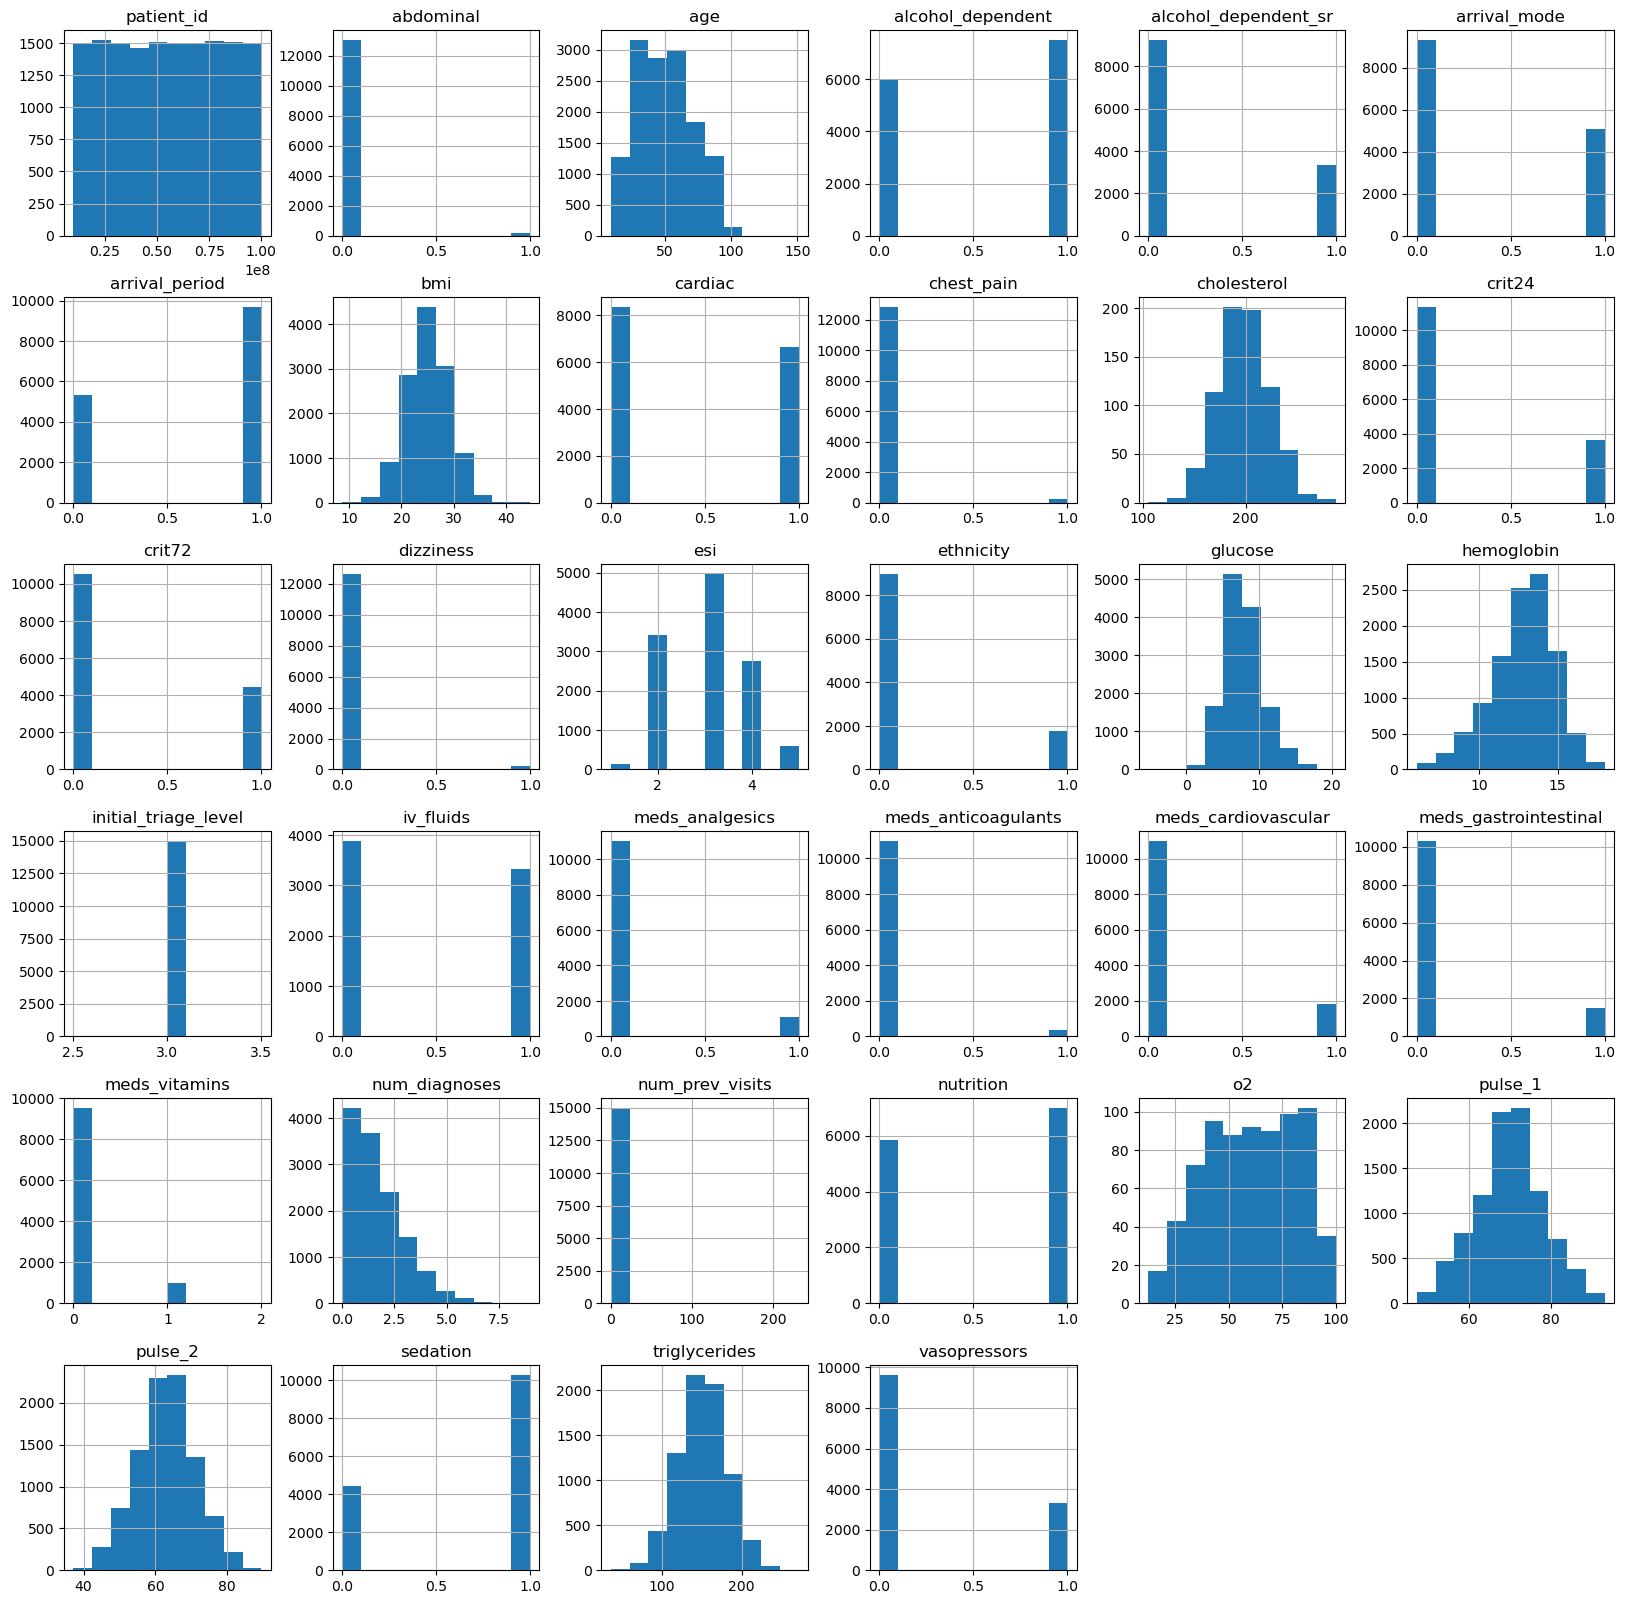

In [ ]:
# plotting histogram distributions of every column

train.hist(figsize=(20,20))


We can see that crit72 is heavily skewed towards 0/no critical event, so will need to try oversampling or undersampling and report balanced accuracy.

The num_prev_visits column might also have weird outliers, and glucose might have negative values, looking at the scale of the histograms.

In [12]:
# summary statistics of num_prev_visits
train['num_prev_visits'].describe()

count    14998.000000
mean         5.065475
std          3.552272
min          0.000000
25%          3.000000
50%          5.000000
75%          7.000000
max        231.000000
Name: num_prev_visits, dtype: float64

<Axes: >

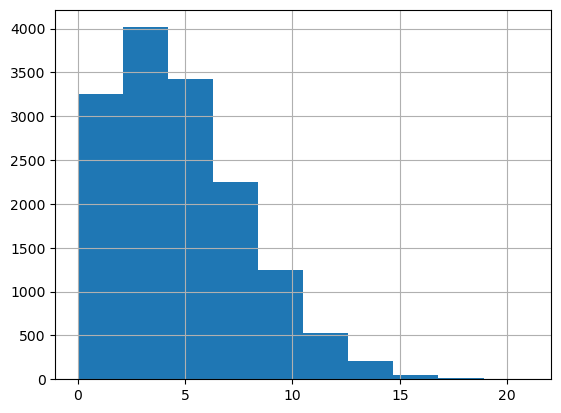

In [17]:
# distribution of num_prev_visits without outliers
train[train['num_prev_visits'] < 25]['num_prev_visits'].hist()

In [18]:
# summary statistics of glucose
train['glucose'].describe()

count    13527.000000
mean         7.879540
std          2.700934
min         -5.213200
25%          6.029476
50%          7.586152
75%          9.406759
max         20.512638
Name: glucose, dtype: float64

There are negative values of glucose which is impossible so will add a function to drop negative values

## Preprocessing Functions

In [15]:
# selecting features to remove
# some features have a lot of missing values, so we will remove them - cholesterol and o2
# from looking at the data dictionary, can see that other features could introduce temporal leakage, so we will remove them as well
# the model needs to be usable on admission - crit24, iv_fluids, sedation, vasorepressors, pulse_2, and nutrition are all features assessed in the AMU so will cause temporal leakage
# initial_triage_level also doesn't look helpful as every data point is 3

def remove_features(df):
    df = df.drop(columns=['patient_id', 'cholesterol', 'o2', 'crit24', 'iv_fluids', 'sedation', 'vasorepressors', 'pulse_2', 'nutrition', 'initial_triage_level'])
    return df

# this function will go in the preprocessing pipeline so it can be applied to the unseen test data as well

In [6]:
# the model needs to predict adult patients, ie age >= 18, so need to make a function that removes patients under 18 years old

def remove_under_18(df):
    df = df[df['age'] >= 18]
    return df

In [ ]:
# creating a function to filter out num_prev_visits outliers - will use 25 as the cut off as the histogram shows that there are very few data points above this value and it is likely that they are errors in data entry

def remove_num_prev_visits_outliers(df):
    df = df[df['num_prev_visits'] < 25]
    return df

In [19]:
# function to drop negative values in glucose as are likely to be errors in data entry 

def remove_negative_glucose(df):
    df = df[df['glucose'] >= 0]
    return df

**You will not be able to run the code below as you do not have access to `y_test`**. 

In [ ]:
# do not run this code
y_test = pd.read_csv("y_test.csv")

balanced_accuracy = balanced_accuracy_score(y_true = y_test, y_pred = y_predict_ensemble)

print(f'Final balanced accuracy: {balanced_accuracy:.6f}')